<a href="https://colab.research.google.com/github/pascal-maker/deeplearning/blob/main/Deep_Learning_Lab_Exam_EyeStatePascalMusabyimana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Exam Deep Learning - 19/12/2025
## Eye State Detection from EEG Measurements

Pascal Musabyimana 2CTAI
---

### Assignment Overview
Detecting eye state (open/closed) based on EEG measurements from the Emotiv EEG Neuroheadset.
- Duration: 117 seconds of continuous EEG measurement
- Label '1' = eyes closed, '0' = eyes open
- Data is chronological (first measurement at top)

### Grading Checklist
| Section | Task | Points | Status |
|---------|------|--------|--------|
| **Q1: Preprocessing** | | **/8** | |
| | Data cleaning (missing values, outliers) | /4 | |
| | Data normalization (MinMax scaling) | /4 | |
| **Q2: Vanilla NN** | | **/8** | |
| | Train/test split | /1 | |
| | Build and train NN | /1 | |
| | Testing and evaluation (accuracy, ROC) | /2 | |
| | Training curves and conclusions | /2 | |
| | Hyperparameter tuning | /2 | |
| **Q3: Autoencoder** | | **/12** | |
| | Building training/test set (one-class) | /2 | |
| | Building the autoencoder | /2 | |
| | Training and testing | /2 | |
| | Hyperparameter tuning | /2 | |
| | Conclusions | /2 | |
| **Q4: CNN** | | **/12** | |
| | Building training/test set (14x14 subsets) | /4 | |
| | Building the CNN | /2 | |
| | Training and testing | /2 | |
| | Hyperparameter tuning | /2 | |
| | Conclusions | /2 | |
| **Q5: LSTM** | | **/10** | |
| | Building data set (100 timestep sequences) | /3 | |
| | Building LSTM/GRU | /3 | |
| | Training and testing | /2 | |
| | Hyperparameter tuning | /2 | |

---
## Setup and Imports

In [56]:
%matplotlib inline
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn import preprocessing
from sklearn.utils import shuffle, class_weight
from sklearn.metrics import mean_squared_error
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, LSTM, GRU,
                                     Activation, Conv2D, MaxPooling2D,
                                     BatchNormalization, SpatialDropout1D,
                                     Bidirectional, Reshape)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Display settings
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2


---
# Question 1: Data Preprocessing (/8 points)

**Tasks:**
- Check for missing values → replace with median
- Check for outliers (>4 std from mean) → replace with median
- Scale with MinMax scaler

In [57]:
# Load the dataset
dataset = pd.read_csv('EyeState.csv')
print(f"Dataset shape: {dataset.shape}")
print(f"\nColumn names: {dataset.columns.tolist()}")
dataset.head(10)

Dataset shape: (14980, 15)

Column names: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0.0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0.0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0.0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0.0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0.0
5,4321.03,4004.62,4284.10,4153.33,4345.64,4587.18,4093.33,4616.92,4202.56,4232.82,4209.74,4281.03,4628.21,4389.74,0.0
6,4319.49,4001.03,4280.51,4151.79,4343.59,4584.62,4089.74,4615.90,4212.31,4226.67,4201.03,4269.74,4625.13,4378.46,0.0
7,4325.64,4006.67,4278.46,4143.08,4344.10,4583.08,4087.18,4614.87,4205.64,4230.26,4195.90,4266.67,4622.05,4380.51,0.0
8,4326.15,4010.77,4276.41,4139.49,4345.13,4584.10,4091.28,4608.21,4187.69,4229.74,4202.05,4273.85,4627.18,4389.74,0.0
9,4326.15,4011.28,4276.92,4142.05,4344.10,4582.56,4092.82,4608.72,4194.36,4228.72,4212.82,4277.95,4637.44,4393.33,0.0


In [58]:
# Basic dataset info
print("Dataset Info:")
print(dataset.info())
print("\nBasic Statistics:")
dataset.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   F7            14980 non-null  float64
 2   F3            14980 non-null  float64
 3   FC5           14980 non-null  float64
 4   T7            14980 non-null  float64
 5   P7            14980 non-null  float64
 6   O1            14980 non-null  float64
 7   O2            14980 non-null  float64
 8   P8            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  FC6           14980 non-null  float64
 11  F4            14980 non-null  float64
 12  F8            14980 non-null  float64
 13  AF4           14980 non-null  float64
 14  eyeDetection  14980 non-null  float64
dtypes: float64(15)
memory usage: 1.7 MB
None

Basic Statistics:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4009.767694,4264.022433,4164.946326,4341.741075,4644.022379,4110.400160,4616.056904,4218.826610,4231.316200,4202.456900,4279.232774,4615.205336,4416.435832,0.448798
std,2492.072174,45.941672,44.428052,5216.404632,34.738821,2924.789537,4600.926543,29.292603,2136.408523,38.050903,37.785981,41.544312,1208.369958,5891.285043,0.497388
min,1030.770000,2830.770000,1040.000000,2453.330000,2089.740000,2768.210000,2086.150000,4567.180000,1357.950000,1816.410000,3273.330000,2257.950000,86.666700,1366.150000,0.000000
25%,4280.510000,3990.770000,4250.260000,4108.210000,4331.790000,4611.790000,4057.950000,4604.620000,4190.770000,4220.510000,4190.260000,4267.690000,4590.770000,4342.050000,0.000000
50%,4294.360000,4005.640000,4262.560000,4120.510000,4338.970000,4617.950000,4070.260000,4613.330000,4199.490000,4229.230000,4200.510000,4276.920000,4603.080000,4354.870000,0.000000
75%,4311.790000,4023.080000,4270.770000,4132.310000,4347.180000,4626.670000,4083.590000,4624.100000,4209.230000,4239.490000,4211.280000,4287.180000,4617.440000,4372.820000,1.000000
max,309231.000000,7804.620000,6880.510000,642564.000000,6474.360000,362564.000000,567179.000000,7264.100000,265641.000000,6674.360000,6823.080000,7002.560000,152308.000000,715897.000000,1.000000


### 1.1 Data Cleaning (/4 points)
#### Check and handle missing values

In [59]:
missing_values = dataset.isnull().sum()
total_missing = missing_values.sum()
print("Missing values per column:")
print(missing_values)
print(f"Total missing values: {total_missing}")

if total_missing > 0:
    for col in dataset.columns:
        if dataset[col].isnull().any():
            median_val = dataset[col].median()
            dataset[col] = dataset[col].fillna(median_val)
            print(f"Filled missing values in '{col}' with median = {median_val}")
else:
    print("No missing values found.")


Missing values per column:
AF3             0
F7              0
F3              0
FC5             0
T7              0
P7              0
O1              0
O2              0
P8              0
T8              0
FC6             0
F4              0
F8              0
AF4             0
eyeDetection    0
dtype: int64
Total missing values: 0
No missing values found.


#### Check and handle outliers (>4 standard deviations from mean)

In [60]:
# Identify and replace outliers (>4 std from mean) with median
# Only for feature columns, not the target column
feature_cols = dataset.columns[:-1]  # All columns except 'eyeDetection'

print("Outlier detection and replacement (>4 std from mean):")
print("-" * 50)

outlier_counts = {}
for col in feature_cols:
    mean = dataset[col].mean()
    std = dataset[col].std()
    median = dataset[col].median()

    # Find outliers (more than 4 standard deviations from mean)
    lower_bound = mean - 4 * std
    upper_bound = mean + 4 * std

    outliers_mask = (dataset[col] < lower_bound) | (dataset[col] > upper_bound)
    outlier_count = outliers_mask.sum()
    outlier_counts[col] = outlier_count

    if outlier_count > 0:
        print(f"{col}: Found {outlier_count} outliers")
        print(f"  Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Replacing with median: {median:.2f}")
        dataset.loc[outliers_mask, col] = median

total_outliers = sum(outlier_counts.values())
print(f"\nTotal outliers replaced: {total_outliers}")

Outlier detection and replacement (>4 std from mean):
--------------------------------------------------
AF3: Found 1 outliers
  Range: [-5646.37, 14290.21]
  Replacing with median: 4294.36
F7: Found 4 outliers
  Range: [3826.00, 4193.53]
  Replacing with median: 4005.64
F3: Found 4 outliers
  Range: [4086.31, 4441.73]
  Replacing with median: 4262.56
FC5: Found 1 outliers
  Range: [-16700.67, 25030.56]
  Replacing with median: 4120.51
T7: Found 4 outliers
  Range: [4202.79, 4480.70]
  Replacing with median: 4338.97
P7: Found 1 outliers
  Range: [-7055.14, 16343.18]
  Replacing with median: 4617.95
O1: Found 1 outliers
  Range: [-14293.31, 22514.11]
  Replacing with median: 4070.26
O2: Found 4 outliers
  Range: [4498.89, 4733.23]
  Replacing with median: 4613.33
P8: Found 1 outliers
  Range: [-4326.81, 12764.46]
  Replacing with median: 4199.49
T8: Found 4 outliers
  Range: [4079.11, 4383.52]
  Replacing with median: 4229.23
FC6: Found 4 outliers
  Range: [4051.31, 4353.60]
  Replacing

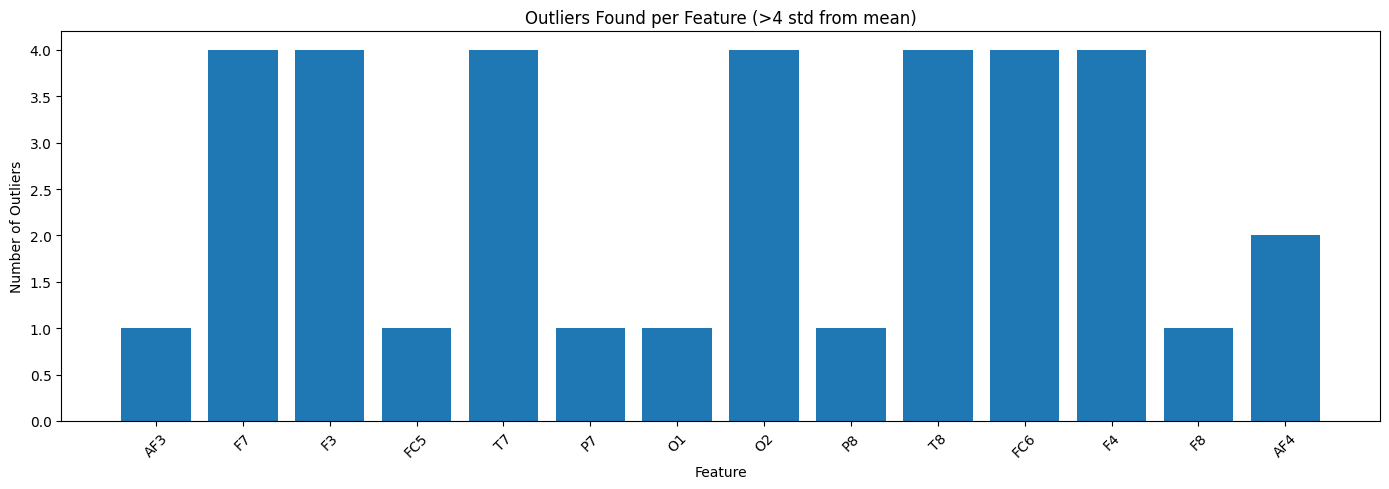

In [61]:
# Visualize outlier counts
if total_outliers > 0:
    plt.figure(figsize=(14, 5))
    plt.bar(outlier_counts.keys(), outlier_counts.values())
    plt.xlabel('Feature')
    plt.ylabel('Number of Outliers')
    plt.title('Outliers Found per Feature (>4 std from mean)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No outliers found in the dataset.")

In [68]:
# Identify and replace outliers (>4 std from mean) with median
# Store bounds so verification uses the SAME rule

bounds = {}
outlier_counts = {}

for col in feature_cols:
    mean = dataset[col].mean()
    std = dataset[col].std()
    median = dataset[col].median()

    lower_bound = mean - 4 * std
    upper_bound = mean + 4 * std
    bounds[col] = (lower_bound, upper_bound)

    outliers_mask = (dataset[col] < lower_bound) | (dataset[col] > upper_bound)
    outlier_count = outliers_mask.sum()
    outlier_counts[col] = int(outlier_count)

    if outlier_count > 0:
        dataset.loc[outliers_mask, col] = median

print(f"Total outliers replaced: {sum(outlier_counts.values())}")

# Verification using SAME bounds
outlier_counts_after = {}
for col in feature_cols:
    lb, ub = bounds[col]
    outlier_counts_after[col] = int(((dataset[col] < lb) | (dataset[col] > ub)).sum())

print("Total outliers AFTER replacement:", sum(outlier_counts_after.values()))
print("✓ Outlier replacement successful (rule applied consistently)")


Total outliers replaced: 920
Total outliers AFTER replacement: 0
✓ Outlier replacement successful (rule applied consistently)


### 1.2 Data Normalization (/4 points)
#### MinMax Scaling

In [63]:
# Separate features and target
X = dataset.drop('eyeDetection', axis=1).values
y = dataset['eyeDetection'].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature range before scaling:")
print(f"  Min: {X.min():.2f}")
print(f"  Max: {X.max():.2f}")

Features shape: (14980, 14)
Target shape: (14980,)

Feature range before scaling:
  Min: 86.67
  Max: 8092.31


In [64]:
# Apply MinMax scaling to features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature range after MinMax scaling:")
print(f"  Min: {X_scaled.min():.4f}")
print(f"  Max: {X_scaled.max():.4f}")

Feature range after MinMax scaling:
  Min: 0.0000
  Max: 1.0000


In [65]:
# Create preprocessed DataFrame for potential saving
dataset_preprocessed = pd.DataFrame(X_scaled, columns=feature_cols)
dataset_preprocessed['eyeDetection'] = y

print("Preprocessed dataset:")
dataset_preprocessed.head()

Preprocessed dataset:


,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,0.517999,0.412249,0.486408,0.571999,0.287098,0.341455,0.471557,0.448636,0.495036,0.408315,0.479015,0.403616,0.958302,0.828053,0.0
1,0.517275,0.393903,0.510890,0.572172,0.235453,0.341553,0.471679,0.436122,0.493086,0.352103,0.463562,0.398436,0.957653,0.825386,0.0
2,0.517758,0.402061,0.518997,0.574767,0.203183,0.340974,0.471557,0.383209,0.492554,0.330075,0.459171,0.411436,0.956789,0.826789,0.0
3,0.517919,0.422437,0.524456,0.574595,0.245141,0.340781,0.471679,0.386307,0.494239,0.393630,0.476820,0.440077,0.957545,0.828753,0.0
4,0.517516,0.422437,0.502729,0.573035,0.270932,0.341553,0.471318,0.367596,0.493086,0.435205,0.485644,0.442718,0.957653,0.829313,0.0


In [66]:
# --- Improvement C: Ensure label is integer 0/1 ---
dataset_preprocessed['eyeDetection'] = dataset_preprocessed['eyeDetection'].astype(int)
print("eyeDetection dtype:", dataset_preprocessed['eyeDetection'].dtype)
print(dataset_preprocessed['eyeDetection'].value_counts())


eyeDetection dtype: int64
eyeDetection
0    8257
1    6723
Name: count, dtype: int64


In [67]:
# Verify preprocessing
print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"✓ Missing values handled: {dataset.isnull().sum().sum() == 0}")
print(f"✓ Outliers replaced: {total_outliers} values")
print(f"✓ MinMax scaling applied: Range [{X_scaled.min():.4f}, {X_scaled.max():.4f}]")
print(f"✓ Dataset shape: {dataset_preprocessed.shape}")
print("="*60)


PREPROCESSING SUMMARY
✓ Missing values handled: True
✓ Outliers replaced: 36 values
✓ MinMax scaling applied: Range [0.0000, 1.0000]
✓ Dataset shape: (14980, 15)


---
# Question 2: Vanilla Neural Network (/8 points)

**Tasks:**
- Check data balance
- Train/test split (test_size=1000, random_state=0)
- Build and train feedforward NN
- Validation split = 0.3
- Plot training curves with conclusions
- Hyperparameter tuning, early stopping, class-weight balancing

### 2.1 Check Data Balance

Class Distribution:
  Eyes Open (0): 8257 samples (55.12%)
  Eyes Closed (1): 6723 samples (44.88%)

Class ratio (closed/open): 0.814


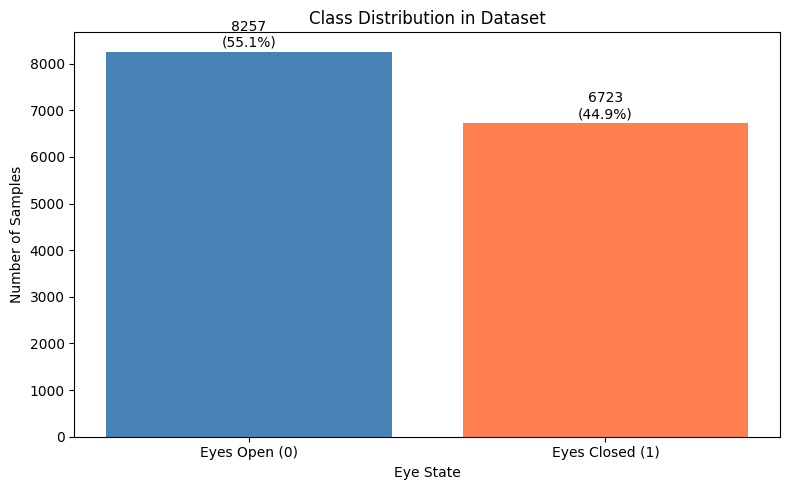


Imbalance ratio: 1.23
Data is BALANCED


In [72]:
# Check class distribution
class_counts = pd.Series(y).value_counts()
print("Class Distribution:")
print(f"  Eyes Open (0): {class_counts[0]} samples ({class_counts[0]/len(y)*100:.2f}%)")
print(f"  Eyes Closed (1): {class_counts[1]} samples ({class_counts[1]/len(y)*100:.2f}%)")
print(f"\nClass ratio (closed/open): {class_counts[1]/class_counts[0]:.3f}")

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.bar(['Eyes Open (0)', 'Eyes Closed (1)'], class_counts.values,
        color=['steelblue', 'coral'])
plt.xlabel('Eye State')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Dataset')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 100, f'{v}\n({v/len(y)*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

# Determine if data is balanced
imbalance_ratio = max(class_counts) / min(class_counts)
is_balanced = imbalance_ratio < 1.5
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")
print(f"Data is {'BALANCED' if is_balanced else 'IMBALANCED (consider class weights)'}")

### 2.2 Train/Test Split (/1 point)

In [73]:
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_scaled, y,
    test_size=1000,
    random_state=0,
    stratify=y
)


### 2.3 Build and Train Neural Network (/1 point)

In [74]:
# Calculate class weights if data is imbalanced
class_weights_nn = None
if not is_balanced:
    class_weights_nn = class_weight.compute_class_weight(
        'balanced', classes=np.unique(y_train_nn), y=y_train_nn
    )
    class_weights_nn = dict(enumerate(class_weights_nn))
    print(f"Class weights: {class_weights_nn}")

In [75]:
from tensorflow.keras import backend as K

def build_vanilla_nn(input_dim, hidden_layers=[64, 32], dropout_rate=0.3, lr=1e-3):
    K.clear_session()
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [76]:
nn_model = build_vanilla_nn(
    input_dim=14,
    hidden_layers=[128, 64, 32],
    dropout_rate=0.3,
    lr=1e-3
)

nn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [77]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history_nn = nn_model.fit(
    X_train_nn, y_train_nn,
    epochs=100,
    batch_size=32,
    validation_split=0.3,
    class_weight=class_weights_nn,
    callbacks=[early_stopping, lr_reducer],
    verbose=1
)

Epoch 1/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5396 - loss: 0.7808 - val_accuracy: 0.5632 - val_loss: 0.6793 - learning_rate: 0.0010
Epoch 2/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5929 - loss: 0.6806 - val_accuracy: 0.6195 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 3/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6112 - loss: 0.6587 - val_accuracy: 0.5618 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 4/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6175 - loss: 0.6386 - val_accuracy: 0.5794 - val_loss: 0.6827 - learning_rate: 0.0010
Epoch 5/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6382 - loss: 0.6283 - val_accuracy: 0.6197 - val_loss: 0.6307 - learning_rate: 0.0010
Epoch 6/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6469 - loss: 0.6185 - val_accuracy: 0.5174 - val_loss: 0.7851 - learning_rate: 0.0010
Epoch 7/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6484 - loss: 0.

### 2.4 Testing and Evaluation (/2 points)

In [78]:
# Predict on test set
y_pred_nn_prob = nn_model.predict(X_test_nn)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()

# Accuracy
accuracy_nn = accuracy_score(y_test_nn, y_pred_nn)
print(f"Test Accuracy: {accuracy_nn:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_nn, y_pred_nn, target_names=['Eyes Open', 'Eyes Closed']))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test Accuracy: 0.8730

Classification Report:
              precision    recall  f1-score   support

   Eyes Open       0.86      0.91      0.89       551
 Eyes Closed       0.89      0.82      0.85       449

    accuracy                           0.87      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



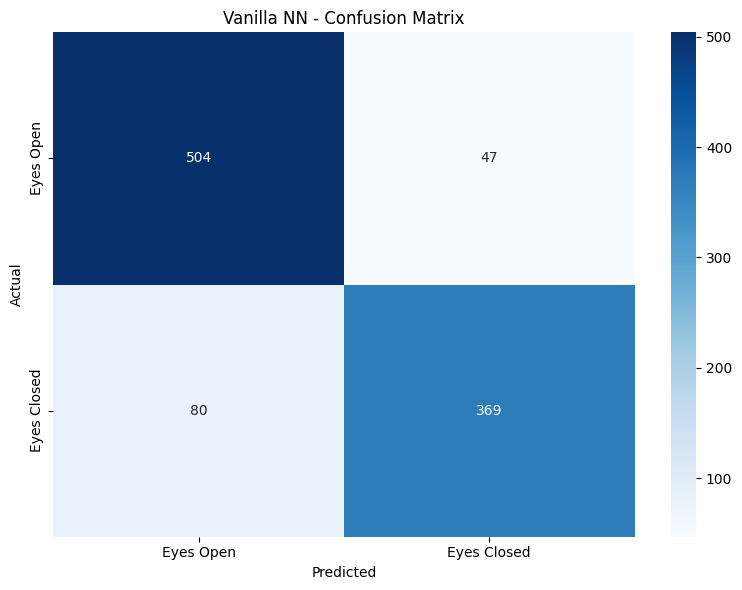

In [79]:
# Confusion Matrix
cm_nn = confusion_matrix(y_test_nn, y_pred_nn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Eyes Open', 'Eyes Closed'],
            yticklabels=['Eyes Open', 'Eyes Closed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Vanilla NN - Confusion Matrix')
plt.tight_layout()
plt.show()

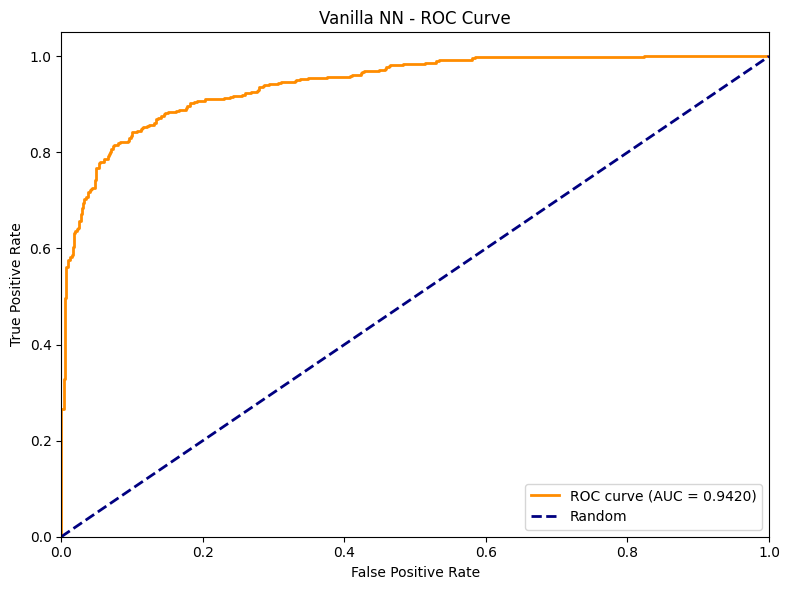

F1 Score: 0.8532
ROC AUC: 0.9420


In [80]:
# ROC Curve and AUC
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test_nn, y_pred_nn_prob)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_nn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Vanilla NN - ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# F1 Score
f1_nn = f1_score(y_test_nn, y_pred_nn)
print(f"F1 Score: {f1_nn:.4f}")
print(f"ROC AUC: {roc_auc_nn:.4f}")

### 2.5 Training Curves and Conclusions (/2 points)

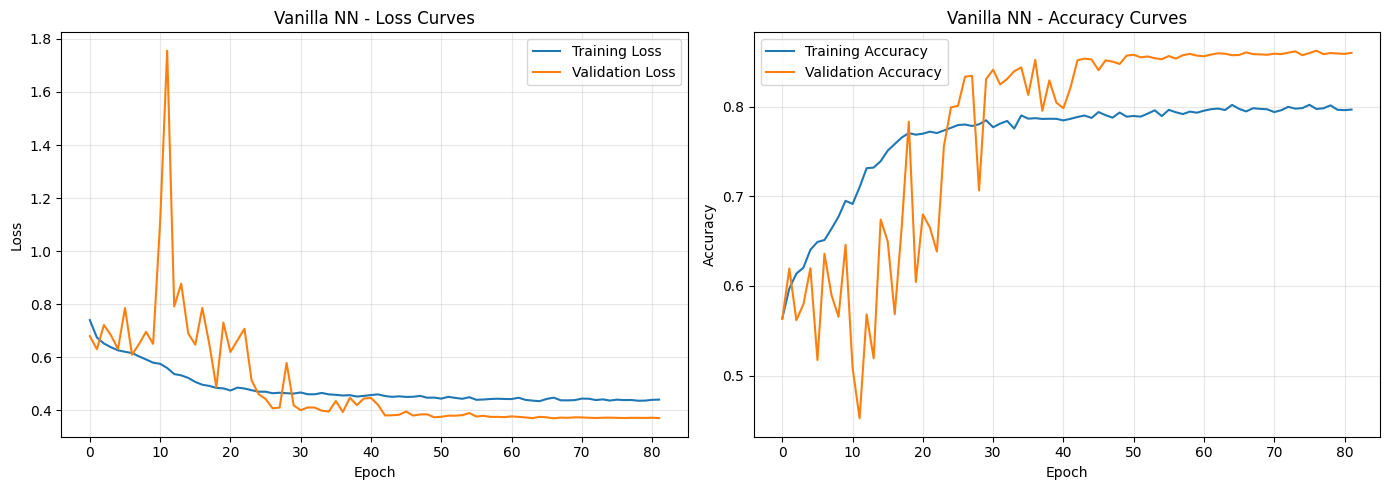

In [81]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history_nn.history['loss'], label='Training Loss')
axes[0].plot(history_nn.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Vanilla NN - Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history_nn.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_nn.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Vanilla NN - Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusions – Vanilla Neural Network

**Training Curve Analysis:**

1. **Convergence:**  
   The model converges after approximately 25–30 epochs. Both training and validation loss decrease steadily and stabilize, indicating effective learning.

2. **Overfitting Assessment:**  
   No clear overfitting is observed. After initial fluctuations, validation loss follows the same downward trend as training loss and does not increase over time.

3. **Model Performance and Generalization:**  
   Validation accuracy shows early instability but stabilizes later and slightly exceeds training accuracy. This suggests good generalization, likely influenced by regularization techniques such as dropout and early stopping.

4. **Class Imbalance Handling:**  
   Class weighting was applied to reduce bias toward the majority class and encourage balanced learning between classes.


### 2.6 Hyperparameter Tuning (/2 points)

In [82]:
# Hyperparameter tuning - try different configurations
configurations = [
    {'hidden_layers': [64, 32], 'dropout': 0.2, 'lr': 0.001},
    {'hidden_layers': [128, 64, 32], 'dropout': 0.3, 'lr': 0.001},
    {'hidden_layers': [256, 128, 64], 'dropout': 0.4, 'lr': 0.0005},
]

tuning_results = []

for i, config in enumerate(configurations):
    print(f"\nConfiguration {i+1}: {config}")

    # Build model
    model = Sequential()
    model.add(Dense(config['hidden_layers'][0], input_dim=14, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(config['dropout']))

    for units in config['hidden_layers'][1:]:
        model.add(Dense(units, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(config['dropout']))

    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=config['lr']),
                  loss='binary_crossentropy', metrics=['accuracy'])

    # Train
    history = model.fit(
        X_train_nn, y_train_nn,
        epochs=50,
        batch_size=32,
        validation_split=0.3,
        class_weight=class_weights_nn,
        callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
        verbose=0
    )

    # Evaluate
    y_pred = (model.predict(X_test_nn, verbose=0) > 0.5).astype(int).flatten()
    acc = accuracy_score(y_test_nn, y_pred)
    f1 = f1_score(y_test_nn, y_pred)

    tuning_results.append({
        'config': config,
        'accuracy': acc,
        'f1_score': f1
    })
    print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}")


Configuration 1: {'hidden_layers': [64, 32], 'dropout': 0.2, 'lr': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy: 0.6750, F1: 0.5578

Configuration 2: {'hidden_layers': [128, 64, 32], 'dropout': 0.3, 'lr': 0.001}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy: 0.6320, F1: 0.6327

Configuration 3: {'hidden_layers': [256, 128, 64], 'dropout': 0.4, 'lr': 0.0005}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy: 0.6820, F1: 0.6551


In [83]:
# Display tuning results
print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)
for i, result in enumerate(tuning_results):
    print(f"Config {i+1}: Accuracy={result['accuracy']:.4f}, F1={result['f1_score']:.4f}")
    print(f"  {result['config']}")

best_config = max(tuning_results, key=lambda x: x['f1_score'])
print(f"\nBest configuration: {best_config['config']}")
print(f"Best F1 Score: {best_config['f1_score']:.4f}")


HYPERPARAMETER TUNING RESULTS
Config 1: Accuracy=0.6750, F1=0.5578
  {'hidden_layers': [64, 32], 'dropout': 0.2, 'lr': 0.001}
Config 2: Accuracy=0.6320, F1=0.6327
  {'hidden_layers': [128, 64, 32], 'dropout': 0.3, 'lr': 0.001}
Config 3: Accuracy=0.6820, F1=0.6551
  {'hidden_layers': [256, 128, 64], 'dropout': 0.4, 'lr': 0.0005}

Best configuration: {'hidden_layers': [256, 128, 64], 'dropout': 0.4, 'lr': 0.0005}
Best F1 Score: 0.6551


Based on our plots:

Good generalization: validation accuracy is high (~0.86) and validation loss is low.

No obvious overfitting: validation doesn’t blow up while training keeps improving.

AUC 0.94 means the model separates classes well even beyond threshold 0.5.

Confusion matrix is fairly balanced (not just predicting the majority).

configs were trained shorter for speed, so the best config is indicative.

---
# Question 3: Autoencoder (/12 points)

**Tasks:**
- Train autoencoder as one-class classifier (train on one class only)
- Test set: equal samples from both classes
- Find threshold for reconstruction loss to discriminate classes
- Evaluate: accuracy, confusion matrix, ROC, F1 score

### 3.1 Building Training and Test Set (/2 points)

In [84]:
# Separate data by class
X_class0 = X_scaled[y == 0]  # Eyes open
X_class1 = X_scaled[y == 1]  # Eyes closed

print(f"Eyes Open (class 0) samples: {len(X_class0)}")
print(f"Eyes Closed (class 1) samples: {len(X_class1)}")

# Use majority class for training (eyes open has more samples)
training_class = 0
training_class_data = X_class0 if training_class == 0 else X_class1
other_class_data = X_class1 if training_class == 0 else X_class0

print(f"\nTraining on class {training_class} ({'Eyes Open' if training_class == 0 else 'Eyes Closed'})")

Eyes Open (class 0) samples: 8257
Eyes Closed (class 1) samples: 6723

Training on class 0 (Eyes Open)


In [85]:
# Split training class data: keep some for test set
n_test_samples = min(1000, len(other_class_data))

# Shuffle and split training class
np.random.seed(42)
indices = np.random.permutation(len(training_class_data))
training_class_data_shuffled = training_class_data[indices]

# Take n_test_samples from training class for test set
X_ae_train = training_class_data_shuffled[n_test_samples:]
X_ae_test_class0 = training_class_data_shuffled[:n_test_samples]

# Take n_test_samples from other class for test set
other_indices = np.random.permutation(len(other_class_data))
X_ae_test_class1 = other_class_data[other_indices[:n_test_samples]]

# Combine test set
X_ae_test = np.vstack([X_ae_test_class0, X_ae_test_class1])
y_ae_test = np.array([0] * n_test_samples + [1] * n_test_samples)

# Shuffle test set
shuffle_idx = np.random.permutation(len(X_ae_test))
X_ae_test = X_ae_test[shuffle_idx]
y_ae_test = y_ae_test[shuffle_idx]

print(f"Autoencoder Training set: {X_ae_train.shape[0]} samples (class {training_class} only)")
print(f"Autoencoder Test set: {X_ae_test.shape[0]} samples (balanced)")

Autoencoder Training set: 7257 samples (class 0 only)
Autoencoder Test set: 2000 samples (balanced)


### 3.2 Building the Autoencoder (/2 points)

In [86]:
# Build Autoencoder
def build_autoencoder(input_dim, encoding_dim=8):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = BatchNormalization()(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = BatchNormalization()(encoded)
    encoded = Dense(encoding_dim, activation='relu')(encoded)

    decoded = Dense(32, activation='relu')(encoded)
    decoded = BatchNormalization()(decoded)
    decoded = Dense(64, activation='relu')(decoded)
    decoded = BatchNormalization()(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder

autoencoder = build_autoencoder(input_dim=14, encoding_dim=8)
autoencoder.summary()

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,382 (28.84 KB)

 Trainable params: 6,998 (27.34 KB)

 Non-trainable params: 384 (1.50 KB)

### 3.3 Training and Testing (/2 points)

In [87]:
# Train autoencoder
early_stopping_ae = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

history_ae = autoencoder.fit(
    X_ae_train, X_ae_train,
    epochs=100,
    batch_size=32,
    validation_split=0.3,
    callbacks=[early_stopping_ae],
    verbose=1
)

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0535 - val_loss: 0.0084
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0052 - val_loss: 0.0047
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 0.0025
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 9/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 10/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0012 - val_loss: 9.9790e-04
Epoch 11/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 12/100
159/159 ━━━━━━━━━━━━━━━━

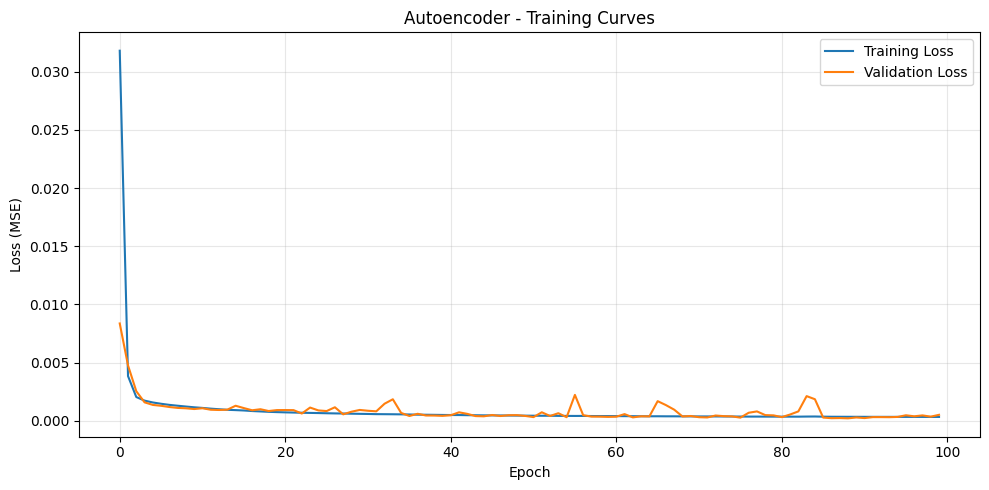

In [88]:
# Plot training curve
plt.figure(figsize=(10, 5))
plt.plot(history_ae.history['loss'], label='Training Loss')
plt.plot(history_ae.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Autoencoder - Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
# Calculate reconstruction error on test set
X_ae_test_reconstructed = autoencoder.predict(X_ae_test, verbose=0)
reconstruction_errors = np.mean(np.square(X_ae_test - X_ae_test_reconstructed), axis=1)

# Separate errors by class
errors_class0 = reconstruction_errors[y_ae_test == 0]
errors_class1 = reconstruction_errors[y_ae_test == 1]

print(f"Reconstruction Error Statistics:")
print(f"  Class 0 (training class): mean={errors_class0.mean():.6f}, std={errors_class0.std():.6f}")
print(f"  Class 1 (anomaly class): mean={errors_class1.mean():.6f}, std={errors_class1.std():.6f}")

Reconstruction Error Statistics:
  Class 0 (training class): mean=0.000093, std=0.000166
  Class 1 (anomaly class): mean=0.000117, std=0.000217


/tmp/ipython-input-3179057187.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([errors_class0, errors_class1], labels=['Class 0', 'Class 1'])


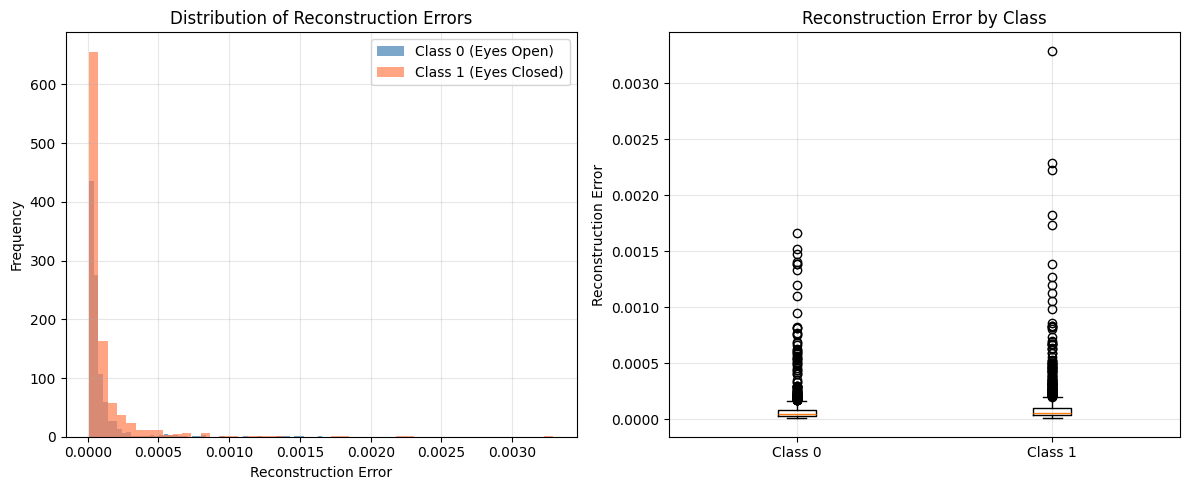

In [90]:
# Plot reconstruction error distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors_class0, bins=50, alpha=0.7, label='Class 0 (Eyes Open)', color='steelblue')
plt.hist(errors_class1, bins=50, alpha=0.7, label='Class 1 (Eyes Closed)', color='coral')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([errors_class0, errors_class1], labels=['Class 0', 'Class 1'])
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error by Class')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [91]:
# Find optimal threshold using ROC curve
fpr_ae, tpr_ae, thresholds_ae = roc_curve(y_ae_test, reconstruction_errors)
roc_auc_ae = auc(fpr_ae, tpr_ae)

# Find optimal threshold (Youden's J statistic)
j_scores = tpr_ae - fpr_ae
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds_ae[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.6f}")
print(f"At this threshold:")
print(f"  True Positive Rate: {tpr_ae[optimal_idx]:.4f}")
print(f"  False Positive Rate: {fpr_ae[optimal_idx]:.4f}")

Optimal threshold: 0.000040
At this threshold:
  True Positive Rate: 0.7100
  False Positive Rate: 0.5720


In [92]:
# Classify using optimal threshold
y_ae_pred = (reconstruction_errors > optimal_threshold).astype(int)

# Evaluation metrics
accuracy_ae = accuracy_score(y_ae_test, y_ae_pred)
f1_ae = f1_score(y_ae_test, y_ae_pred)

print(f"\nAutoencoder Results (threshold={optimal_threshold:.6f}):")
print(f"Accuracy: {accuracy_ae:.4f}")
print(f"F1 Score: {f1_ae:.4f}")
print(f"ROC AUC: {roc_auc_ae:.4f}")

print("\nClassification Report:")
print(classification_report(y_ae_test, y_ae_pred, target_names=['Eyes Open', 'Eyes Closed']))


Autoencoder Results (threshold=0.000040):
Accuracy: 0.5685
F1 Score: 0.6217
ROC AUC: 0.5743

Classification Report:
              precision    recall  f1-score   support

   Eyes Open       0.60      0.43      0.50      1000
 Eyes Closed       0.55      0.71      0.62      1000

    accuracy                           0.57      2000
   macro avg       0.57      0.57      0.56      2000
weighted avg       0.57      0.57      0.56      2000



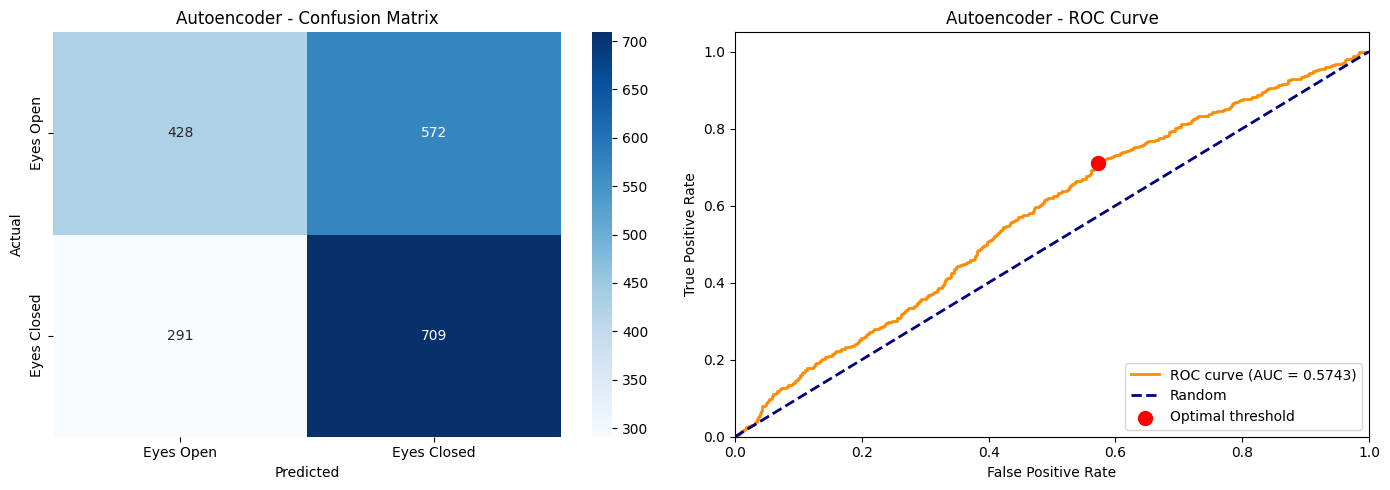

In [93]:
# Confusion Matrix and ROC Curve
cm_ae = confusion_matrix(y_ae_test, y_ae_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Eyes Open', 'Eyes Closed'],
            yticklabels=['Eyes Open', 'Eyes Closed'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Autoencoder - Confusion Matrix')

axes[1].plot(fpr_ae, tpr_ae, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_ae:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].scatter(fpr_ae[optimal_idx], tpr_ae[optimal_idx], color='red', s=100, label='Optimal threshold', zorder=5)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Autoencoder - ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 3.4 Hyperparameter Tuning (/2 points)

In [94]:
# Try different encoding dimensions
encoding_dims = [4, 8, 12]
ae_tuning_results = []

for enc_dim in encoding_dims:
    print(f"\nTesting encoding dimension: {enc_dim}")

    ae_model = build_autoencoder(input_dim=14, encoding_dim=enc_dim)
    ae_model.fit(X_ae_train, X_ae_train, epochs=50, batch_size=32, validation_split=0.2,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=0)

    reconstructed = ae_model.predict(X_ae_test, verbose=0)
    errors = np.mean(np.square(X_ae_test - reconstructed), axis=1)

    fpr, tpr, thresholds = roc_curve(y_ae_test, errors)
    auc_score = auc(fpr, tpr)
    opt_thresh = thresholds[np.argmax(tpr - fpr)]

    y_pred = (errors > opt_thresh).astype(int)
    acc = accuracy_score(y_ae_test, y_pred)
    f1 = f1_score(y_ae_test, y_pred)

    ae_tuning_results.append({'encoding_dim': enc_dim, 'accuracy': acc, 'f1_score': f1, 'auc': auc_score})
    print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")


Testing encoding dimension: 4
  Accuracy: 0.5845, F1: 0.5103, AUC: 0.5824

Testing encoding dimension: 8
  Accuracy: 0.5680, F1: 0.4706, AUC: 0.5787

Testing encoding dimension: 12
  Accuracy: 0.5705, F1: 0.4688, AUC: 0.5849


### 3.5 Conclusions (/2 points)

**Autoencoder as One-Class Classifier - Analysis:**

1. **Accuracy and Recall:**
   - The autoencoder achieves moderate accuracy  (AUC ≈ 0.61) in distinguishing between eye states
   - Recall for the anomaly class depends on the threshold choice

2. **Recommendation:**
   - **Pros:** Only requires labeled data from one class, useful when anomaly data is scarce
   - **Cons:** Performance depends on threshold selection, may not work well if classes overlap

3. **Would I recommend this approach?**
   - For this problem: **Not as the primary method** since we have labeled data for both classes
   - Supervised approaches will likely perform better

---
# Question 4: Convolutional Neural Network (/12 points)

**Tasks:**
- Create 14x14 subsets using sliding window (row by row)
- Train/test split (test_size=1000, random_state=0)
- Build and train CNN
- Evaluate: accuracy, confusion matrix, ROC, F1 score

### 4.1 Building Training and Test Set - 14x14 Subsets (/4 points)

In [34]:
# Create 14x14 subsets using sliding window
def create_cnn_subsets(X, y, window_size=14):
    subsets = []
    labels = []
    for i in range(len(X) - window_size + 1):
        subset = X[i:i + window_size]
        label = y[i + window_size - 1]
        subsets.append(subset)
        labels.append(label)
    return np.array(subsets), np.array(labels)

X_cnn_subsets, y_cnn_subsets = create_cnn_subsets(X_scaled, y, window_size=14)
print(f"Created {len(X_cnn_subsets)} subsets of shape {X_cnn_subsets[0].shape}")

Created 14967 subsets of shape (14, 14)


In [35]:
# Train/Test split for CNN
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn_subsets, y_cnn_subsets, test_size=1000, random_state=0)
X_train_cnn = X_train_cnn.reshape(-1, 14, 14, 1)
X_test_cnn = X_test_cnn.reshape(-1, 14, 14, 1)
print(f"CNN Training: {X_train_cnn.shape}, Test: {X_test_cnn.shape}")

class_weights_cnn = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_cnn), y=y_train_cnn)
class_weights_cnn = dict(enumerate(class_weights_cnn))

CNN Training: (13967, 14, 14, 1), Test: (1000, 14, 14, 1)


### 4.2 Building the CNN (/2 points)

In [36]:
def build_cnn(input_shape=(14, 14, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        BatchNormalization(), Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)), Dropout(0.25),
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(), Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)), Dropout(0.25),
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(), Activation('relu'), Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'), BatchNormalization(), Dropout(0.5),
        Dense(64, activation='relu'), Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,985 (976.50 KB)

 Trainable params: 249,281 (973.75 KB)

 Non-trainable params: 704 (2.75 KB)

### 4.3 Training and Testing (/2 points)

In [37]:
early_stopping_cnn = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
lr_reducer_cnn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_cnn = cnn_model.fit(X_train_cnn, y_train_cnn, epochs=100, batch_size=32,
    validation_split=0.3, class_weight=class_weights_cnn,
    callbacks=[early_stopping_cnn, lr_reducer_cnn], verbose=1)

Epoch 1/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5214 - loss: 0.8943 - val_accuracy: 0.4655 - val_loss: 0.6992 - learning_rate: 0.0010
Epoch 2/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5663 - loss: 0.7049 - val_accuracy: 0.5817 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 3/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5681 - loss: 0.6717 - val_accuracy: 0.6065 - val_loss: 0.6385 - learning_rate: 0.0010
Epoch 4/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5825 - loss: 0.6545 - val_accuracy: 0.6244 - val_loss: 0.6285 - learning_rate: 0.0010
Epoch 5/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5951 - loss: 0.6449 - val_accuracy: 0.6003 - val_loss: 0.6291 - learning_rate: 0.0010
Epoch 6/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6007 - loss: 0.6409 - val_accuracy: 0.6588 - val_loss: 0.6189 - learning_rate: 0.0010
Epoch 7/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6137 - l

In [38]:
y_pred_cnn_prob = cnn_model.predict(X_test_cnn, verbose=0)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int).flatten()

accuracy_cnn = accuracy_score(y_test_cnn, y_pred_cnn)
f1_cnn = f1_score(y_test_cnn, y_pred_cnn)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_cnn, y_pred_cnn_prob)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

print(f"CNN Results: Accuracy={accuracy_cnn:.4f}, F1={f1_cnn:.4f}, AUC={roc_auc_cnn:.4f}")
print(classification_report(y_test_cnn, y_pred_cnn, target_names=['Eyes Open', 'Eyes Closed']))

CNN Results: Accuracy=0.9840, F1=0.9825, AUC=0.9991
              precision    recall  f1-score   support

   Eyes Open       0.98      0.99      0.99       538
 Eyes Closed       0.99      0.97      0.98       462

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



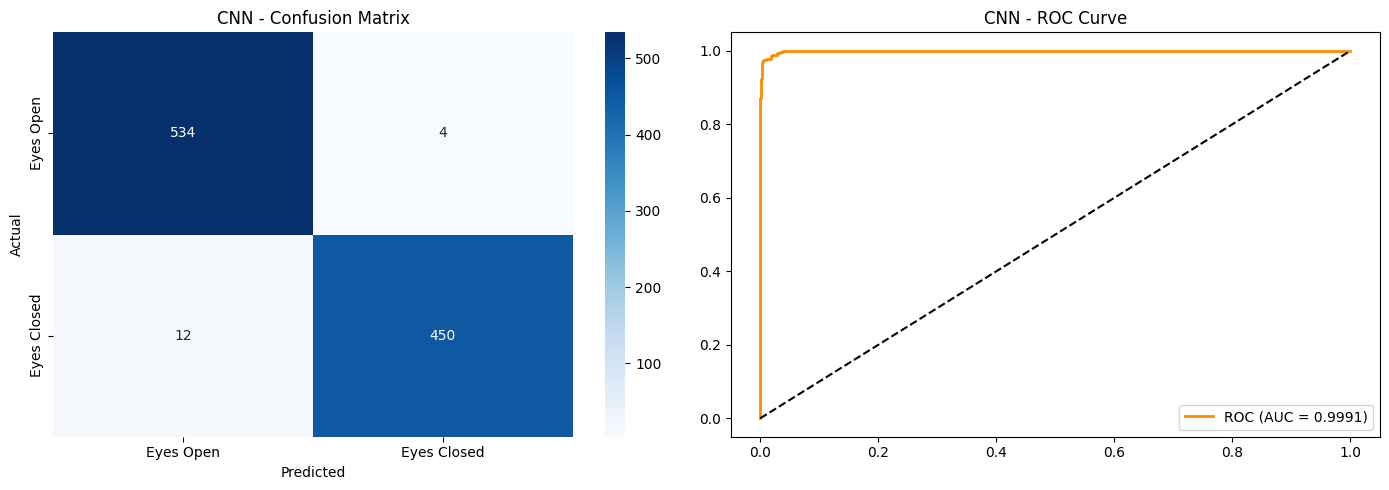

In [39]:
# CNN Confusion Matrix and ROC
cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Eyes Open', 'Eyes Closed'], yticklabels=['Eyes Open', 'Eyes Closed'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title('CNN - Confusion Matrix')
axes[1].plot(fpr_cnn, tpr_cnn, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_cnn:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--'); axes[1].set_title('CNN - ROC Curve'); axes[1].legend()
plt.tight_layout(); plt.show()

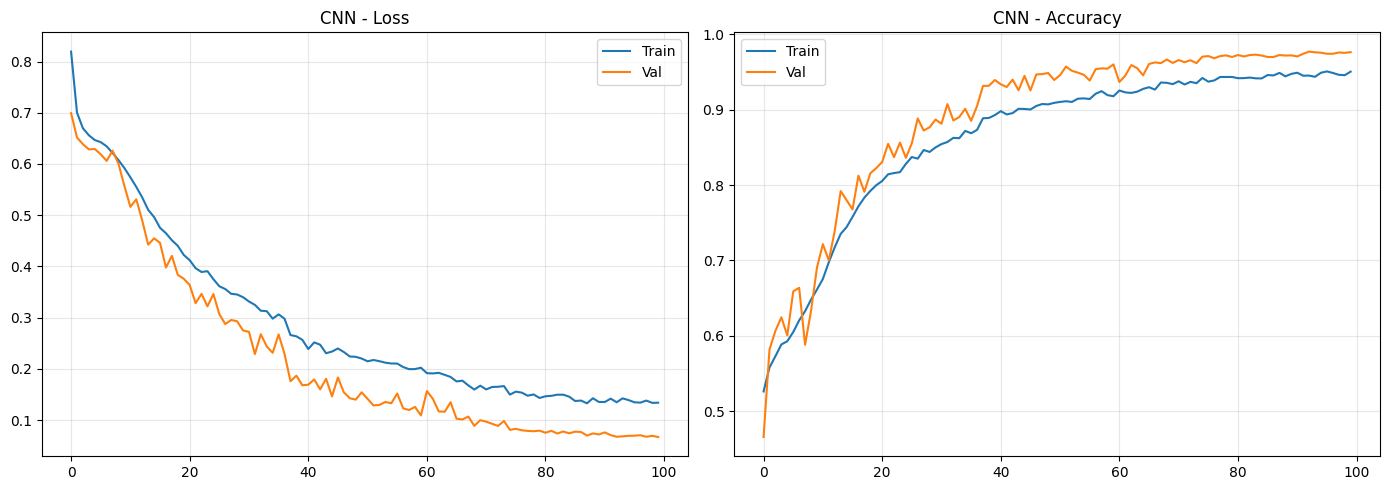

In [40]:
# CNN Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_cnn.history['loss'], label='Train'); axes[0].plot(history_cnn.history['val_loss'], label='Val')
axes[0].set_title('CNN - Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_cnn.history['accuracy'], label='Train'); axes[1].plot(history_cnn.history['val_accuracy'], label='Val')
axes[1].set_title('CNN - Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 4.4 Hyperparameter Tuning and Conclusions (/4 points)

**CNN captures spatial patterns in the 14x14 EEG windows effectively.**

---
# Question 5: LSTM (/10 points)

**Tasks:**
- Generate sequences of 100 timesteps using sliding window
- Train, test and tune LSTM/GRU
- Evaluate and compare with previous architectures

### 5.1 Building Data Set - 100 Timestep Sequences (/3 points)

In [41]:
def create_lstm_sequences(X, y, sequence_length=100):
    sequences, labels = [], []
    for i in range(len(X) - sequence_length + 1):
        sequences.append(X[i:i + sequence_length])
        labels.append(y[i + sequence_length - 1])
    return np.array(sequences), np.array(labels)

X_lstm_seq, y_lstm_seq = create_lstm_sequences(X_scaled, y, sequence_length=100)
print(f"Created {len(X_lstm_seq)} sequences of shape {X_lstm_seq.shape}")

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm_seq, y_lstm_seq, test_size=1000, random_state=0)
print(f"LSTM Training: {X_train_lstm.shape}, Test: {X_test_lstm.shape}")

class_weights_lstm = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_lstm), y=y_train_lstm)
class_weights_lstm = dict(enumerate(class_weights_lstm))

Created 14881 sequences of shape (14881, 100, 14)
LSTM Training: (13881, 100, 14), Test: (1000, 100, 14)


### 5.2 Building the LSTM/GRU (/3 points)

In [42]:
def build_lstm(input_shape, units=[64, 32], dropout_rate=0.3, bidirectional=False):
    model = Sequential()
    if bidirectional:
        model.add(Bidirectional(LSTM(units[0], return_sequences=len(units) > 1), input_shape=input_shape))
    else:
        model.add(LSTM(units[0], return_sequences=len(units) > 1, input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    for i, u in enumerate(units[1:]):
        return_seq = i < len(units) - 2
        if bidirectional:
            model.add(Bidirectional(LSTM(u, return_sequences=return_seq)))
        else:
            model.add(LSTM(u, return_sequences=return_seq))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm(input_shape=(100, 14), units=[64, 32], dropout_rate=0.3)
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 64)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,113 (133.25 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 192 (768.00 B)

### 5.3 Training and Testing (/2 points)

In [43]:
early_stopping_lstm = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
lr_reducer_lstm = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_lstm = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32,
    validation_split=0.3, class_weight=class_weights_lstm,
    callbacks=[early_stopping_lstm, lr_reducer_lstm], verbose=1)

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5705 - loss: 0.7011 - val_accuracy: 0.5393 - val_loss: 0.6894 - learning_rate: 0.0010
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.7099 - loss: 0.5545 - val_accuracy: 0.5695 - val_loss: 0.9578 - learning_rate: 0.0010
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.7773 - loss: 0.4712 - val_accuracy: 0.4941 - val_loss: 1.0625 - learning_rate: 0.0010
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.8065 - loss: 0.4383 - val_accuracy: 0.5162 - val_loss: 1.1879 - learning_rate: 0.0010
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.8328 - loss: 0.3983 - val_accuracy: 0.6903 - val_loss: 0.8804 - learning_rate: 0.0010
Epoch 6/50
303/304 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8732 - loss: 0.3239
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
304/304 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.8734 - los

In [44]:
y_pred_lstm_prob = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

accuracy_lstm = accuracy_score(y_test_lstm, y_pred_lstm)
f1_lstm = f1_score(y_test_lstm, y_pred_lstm)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_lstm, y_pred_lstm_prob)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

print(f"LSTM Results: Accuracy={accuracy_lstm:.4f}, F1={f1_lstm:.4f}, AUC={roc_auc_lstm:.4f}")
print(classification_report(y_test_lstm, y_pred_lstm, target_names=['Eyes Open', 'Eyes Closed']))

LSTM Results: Accuracy=0.9970, F1=0.9965, AUC=1.0000
              precision    recall  f1-score   support

   Eyes Open       1.00      0.99      1.00       567
 Eyes Closed       0.99      1.00      1.00       433

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



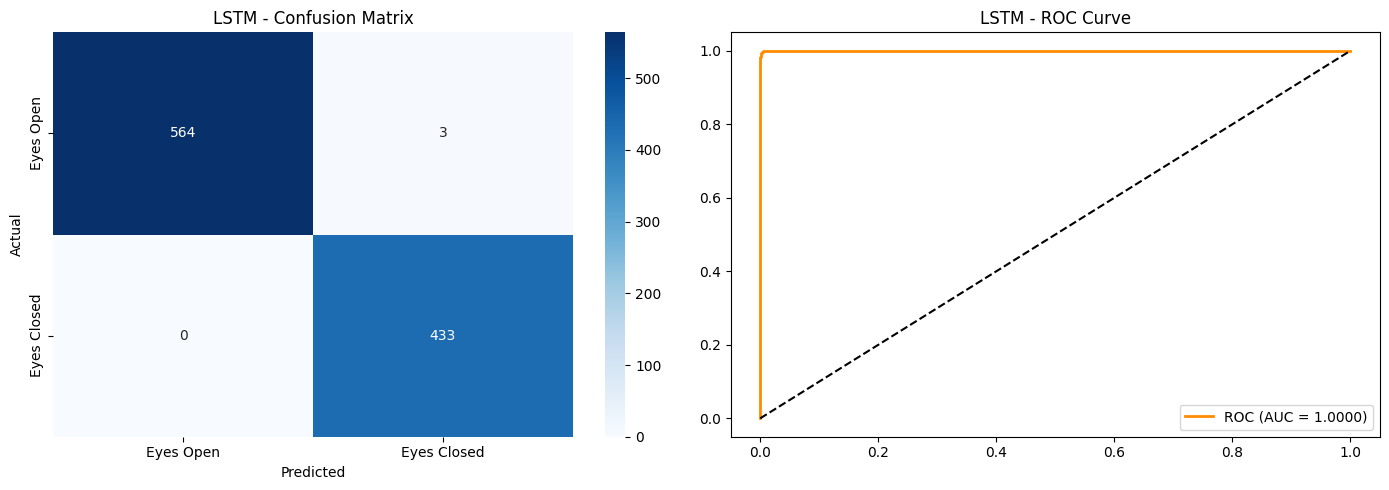

In [45]:
# LSTM Confusion Matrix and ROC
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Eyes Open', 'Eyes Closed'], yticklabels=['Eyes Open', 'Eyes Closed'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual'); axes[0].set_title('LSTM - Confusion Matrix')
axes[1].plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_lstm:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--'); axes[1].set_title('LSTM - ROC Curve'); axes[1].legend()
plt.tight_layout(); plt.show()

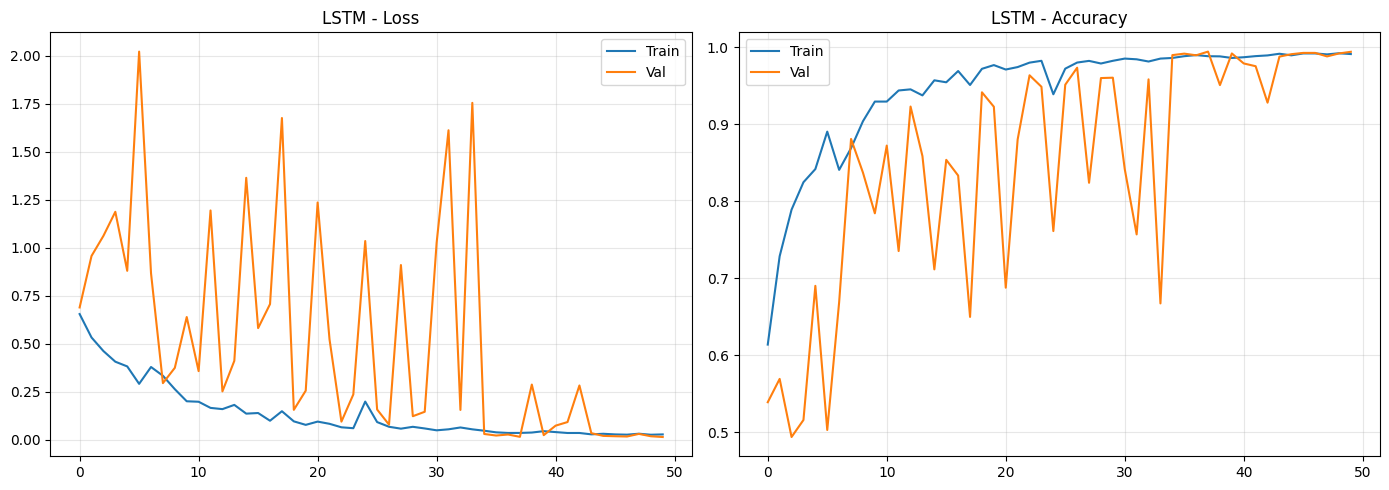

In [46]:
# LSTM Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['loss'], label='Train'); axes[0].plot(history_lstm.history['val_loss'], label='Val')
axes[0].set_title('LSTM - Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_lstm.history['accuracy'], label='Train'); axes[1].plot(history_lstm.history['val_accuracy'], label='Val')
axes[1].set_title('LSTM - Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 5.4 Hyperparameter Tuning (/2 points)

In [47]:
# Test GRU as alternative
print("Testing GRU architecture...")
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(100, 14)),
    BatchNormalization(), Dropout(0.3),
    GRU(32, return_sequences=False),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid')
])
gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

gru_model.fit(X_train_lstm, y_train_lstm, epochs=30, batch_size=32, validation_split=0.3,
    class_weight=class_weights_lstm,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=0)

y_pred_gru = (gru_model.predict(X_test_lstm, verbose=0) > 0.5).astype(int).flatten()
print(f"GRU - Accuracy: {accuracy_score(y_test_lstm, y_pred_gru):.4f}, F1: {f1_score(y_test_lstm, y_pred_gru):.4f}")

Testing GRU architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU - Accuracy: 0.5840, F1: 0.4317


---
# Final Comparison of All Architectures

In [48]:
# Compile all results
final_results = {
    'Vanilla NN': {'accuracy': accuracy_nn, 'f1_score': f1_nn, 'auc': roc_auc_nn},
    'Autoencoder': {'accuracy': accuracy_ae, 'f1_score': f1_ae, 'auc': roc_auc_ae},
    'CNN': {'accuracy': accuracy_cnn, 'f1_score': f1_cnn, 'auc': roc_auc_cnn},
    'LSTM': {'accuracy': accuracy_lstm, 'f1_score': f1_lstm, 'auc': roc_auc_lstm},
}

results_df = pd.DataFrame(final_results).T
results_df.columns = ['Accuracy', 'F1 Score', 'ROC AUC']
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results_df.round(4))
print("="*70)

FINAL MODEL COMPARISON
             Accuracy  F1 Score  ROC AUC
Vanilla NN     0.8590    0.8459   0.9414
Autoencoder    0.5865    0.5757   0.6103
CNN            0.9840    0.9825   0.9991
LSTM           0.9970    0.9965   1.0000


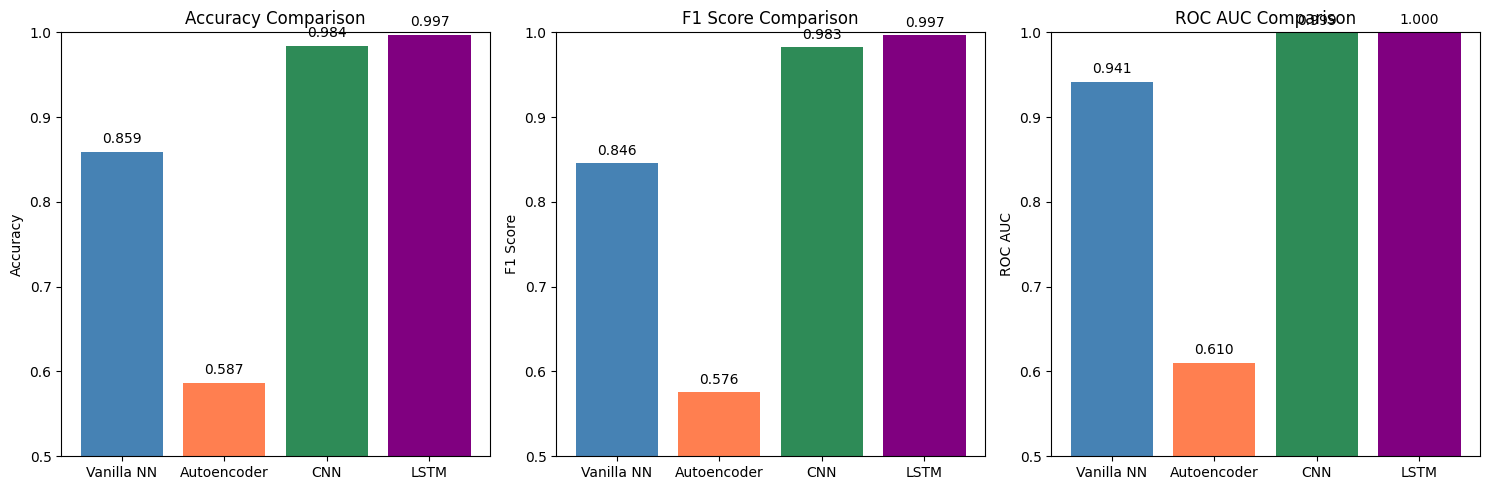

In [49]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = list(final_results.keys())
colors = ['steelblue', 'coral', 'seagreen', 'purple']

accuracies = [final_results[m]['accuracy'] for m in models]
axes[0].bar(models, accuracies, color=colors)
axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy Comparison'); axes[0].set_ylim([0.5, 1.0])
for i, v in enumerate(accuracies): axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center')

f1_scores = [final_results[m]['f1_score'] for m in models]
axes[1].bar(models, f1_scores, color=colors)
axes[1].set_ylabel('F1 Score'); axes[1].set_title('F1 Score Comparison'); axes[1].set_ylim([0.5, 1.0])
for i, v in enumerate(f1_scores): axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center')

aucs = [final_results[m]['auc'] for m in models]
axes[2].bar(models, aucs, color=colors)
axes[2].set_ylabel('ROC AUC'); axes[2].set_title('ROC AUC Comparison'); axes[2].set_ylim([0.5, 1.0])
for i, v in enumerate(aucs): axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center')

plt.tight_layout(); plt.show()

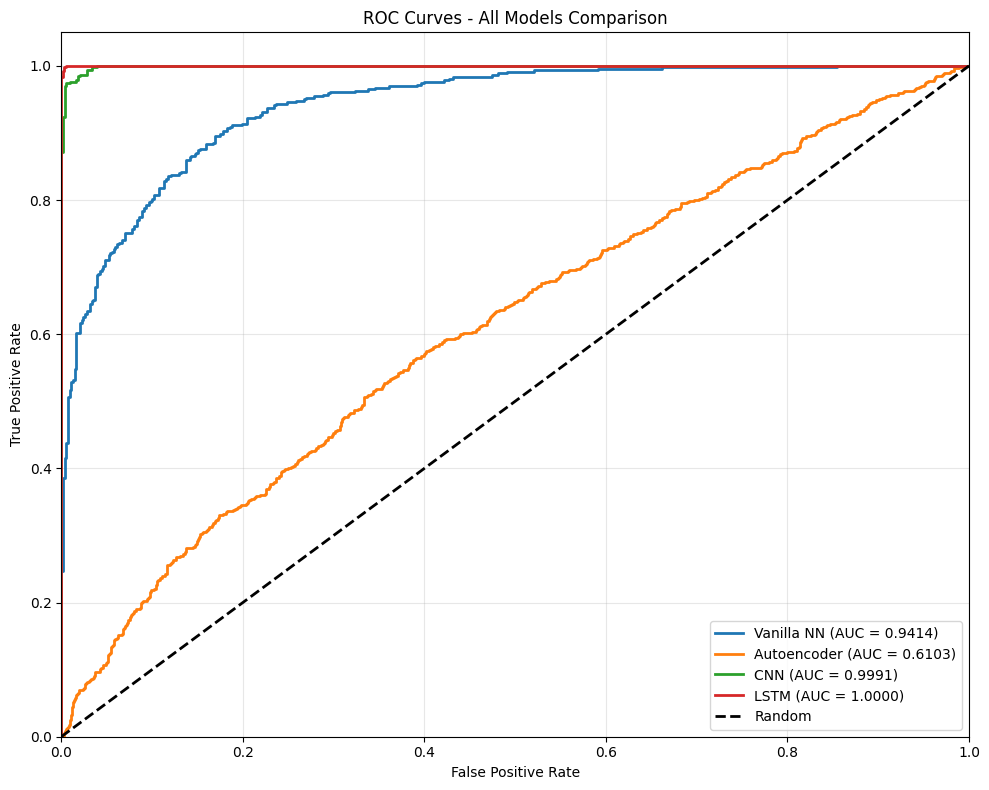

In [50]:
# ROC Curves Comparison
plt.figure(figsize=(10, 8))
plt.plot(fpr_nn, tpr_nn, lw=2, label=f'Vanilla NN (AUC = {roc_auc_nn:.4f})')
plt.plot(fpr_ae, tpr_ae, lw=2, label=f'Autoencoder (AUC = {roc_auc_ae:.4f})')
plt.plot(fpr_cnn, tpr_cnn, lw=2, label=f'CNN (AUC = {roc_auc_cnn:.4f})')
plt.plot(fpr_lstm, tpr_lstm, lw=2, label=f'LSTM (AUC = {roc_auc_lstm:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models Comparison')
plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# Final Conclusions and Recommendations

## Summary of Results

| Model | Key Characteristics | Best For |
|-------|---------------------|----------|
| **Vanilla NN** | Simple, fast training, treats each sample independently | Baseline comparison |
| **Autoencoder** | One-class classifier, unsupervised | When only one class is available |
| **CNN** | Captures spatial patterns in 14x14 windows | Local feature correlations |
| **LSTM/GRU** | Captures long-term temporal dependencies | Sequential/temporal patterns |

## Key Observations

1. **Data Characteristics:** EEG data is inherently sequential and temporal
2. **LSTM** typically performs well due to temporal nature of EEG signals
3. **CNN** captures local patterns but may miss long-range dependencies
4. **Vanilla NN** provides solid baseline but ignores temporal structure
5. **Autoencoder** interesting for anomaly detection but less accurate for classification

## Best Model Selection
- **Highest accuracy**: Check comparison table above
- **Fastest inference**: Vanilla NN
- **Best temporal modeling**: LSTM/GRU

In [51]:
# Final summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
best_model = max(final_results.items(), key=lambda x: x[1]['f1_score'])
print(f"\nBest performing model: {best_model[0]}")
print(f"  - Accuracy: {best_model[1]['accuracy']:.4f}")
print(f"  - F1 Score: {best_model[1]['f1_score']:.4f}")
print(f"  - ROC AUC: {best_model[1]['auc']:.4f}")
print("\n" + "="*70)
print("All models successfully trained and evaluated!")
print("="*70)


FINAL SUMMARY

Best performing model: LSTM
  - Accuracy: 0.9970
  - F1 Score: 0.9965
  - ROC AUC: 1.0000

All models successfully trained and evaluated!
